# Titanic Survival Prediction — Custom Decision Tree and Random Forest

**Roll Number:** *25280065*  
**Course:** AI500 — Machine Learning  
**Assignment:** Project 3 — Decision Trees & Random Forests  

---

### Overview

In this project, we build two models **from scratch** (without using scikit-learn classifiers):

1. **Part 1 — Custom Decision Tree**
2. **Part 2 — Custom Random Forest**
2. **Part 3 — SVM**

We train them on the **Titanic dataset** to predict passenger survival.  
We also analyze model accuracy and compare results.


**Import libraries**

In [50]:
# ==============================
# TO BE IMPLEMENTED
# ==============================

# import are relvant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


### **Part 1 — Custom Decision Tree**

### Load and Prepare Titanic Dataset

In [51]:
# Load training data
data = pd.read_csv("titanic.csv")

print(data.head())
print(data.info())
print(data.isnull().sum())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

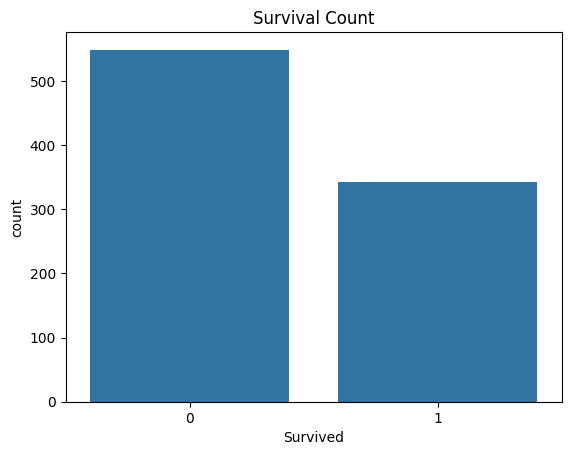

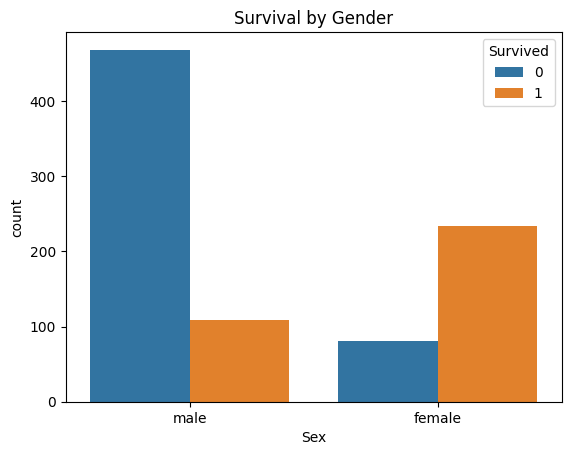

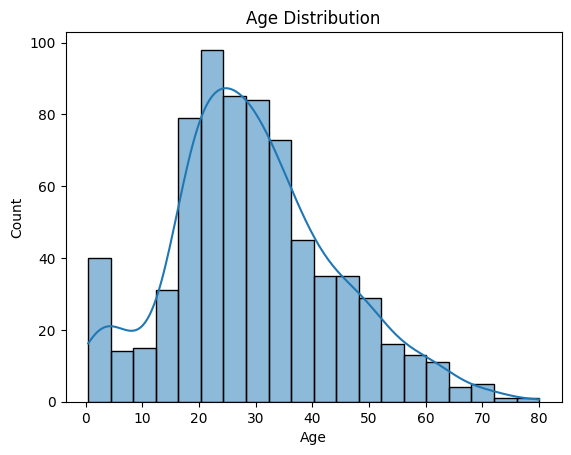

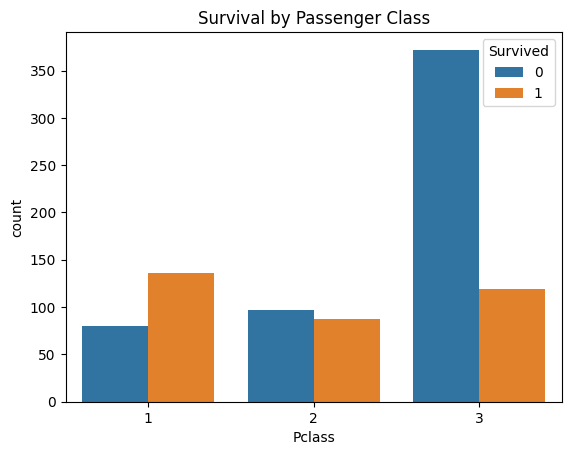

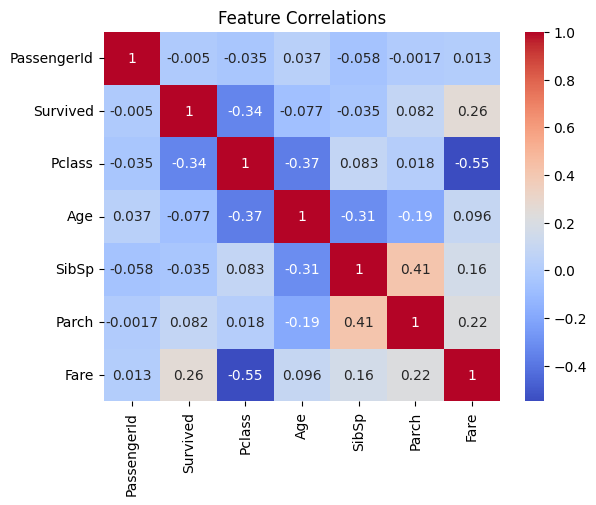

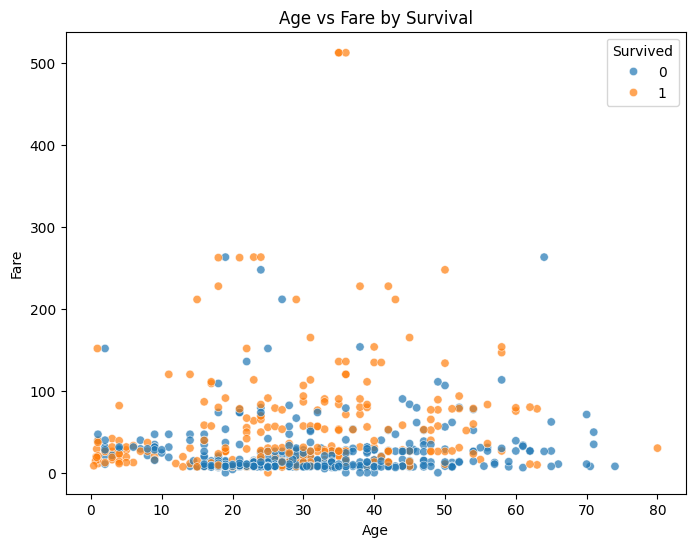

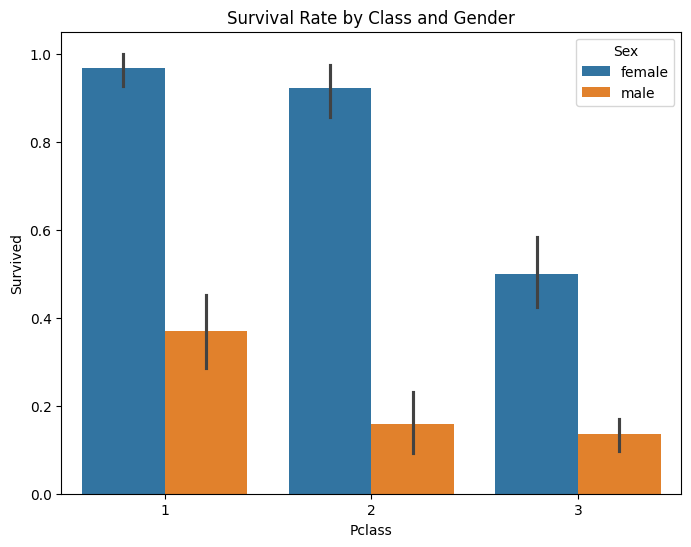

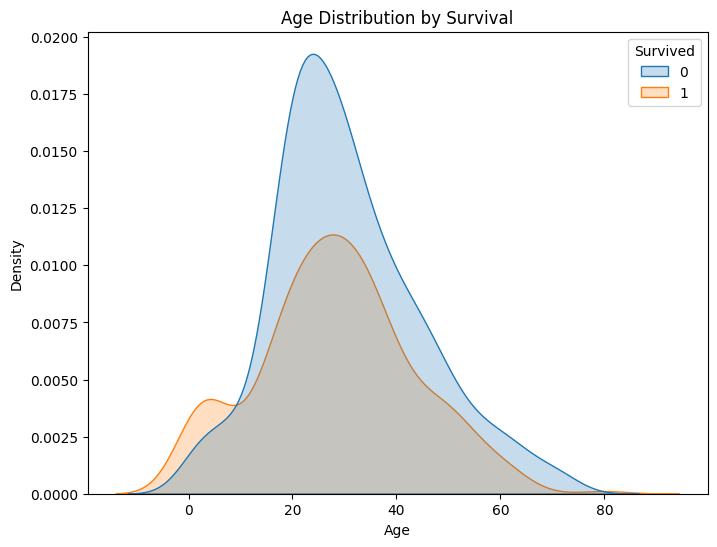

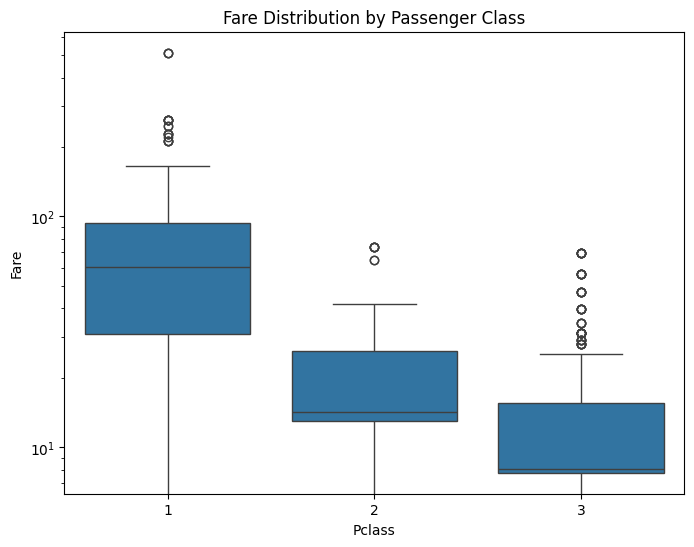

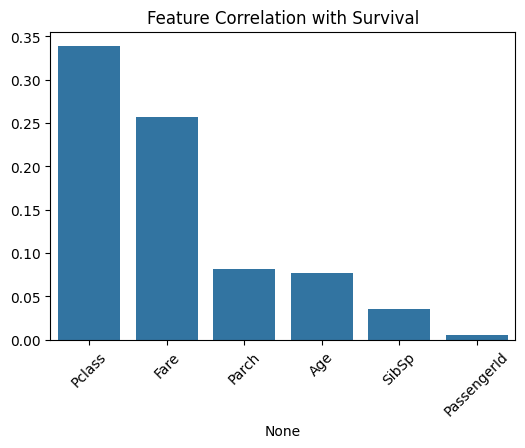

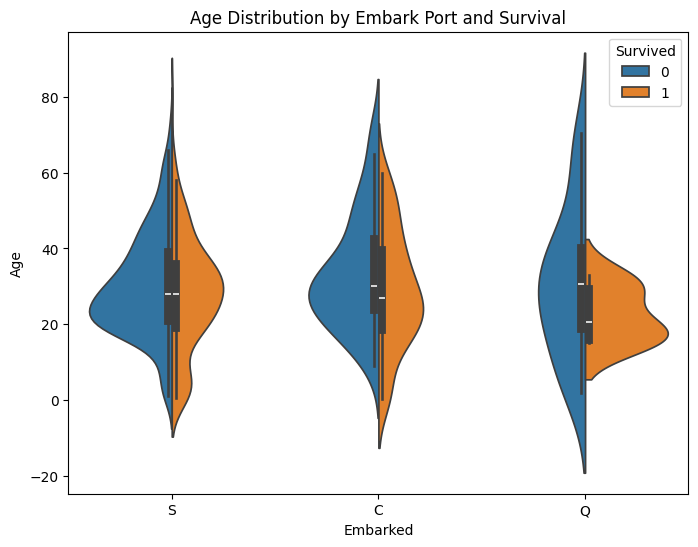

In [52]:
# OPTIONLA EDA only to understand the csv file 

# 1. Survival count
sns.countplot(x='Survived', data=data)
plt.title('Survival Count')
plt.show()
# 2. Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title('Survival by Gender')
plt.show()
# 3. Age distribution
sns.histplot(data['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()
# 4. Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title('Survival by Passenger Class')
plt.show()

# 5. Correlation heatmap (numeric features)
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()


# 2. Age vs Fare (colored by survival)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=data, alpha=0.7)
plt.title('Age vs Fare by Survival')
plt.show()

# 3. Survival by Class and Gender
plt.figure(figsize=(8,6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=data)
plt.title('Survival Rate by Class and Gender')
plt.show()

# 4. Distribution of Age by Survival (Kernel Density)
plt.figure(figsize=(8,6))
sns.kdeplot(data=data, x='Age', hue='Survived', fill=True)
plt.title('Age Distribution by Survival')
plt.show()

# 5. Fare distribution by Class
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Fare', data=data)
plt.title('Fare Distribution by Passenger Class')
plt.yscale('log')  # Skewed data
plt.show()

# 6. Correlation with Survived
corr = data.corr(numeric_only=True)
plt.figure(figsize=(6,4))
sns.barplot(x=corr['Survived'].abs().sort_values(ascending=False)[1:].index,
            y=corr['Survived'].abs().sort_values(ascending=False)[1:].values)
plt.title('Feature Correlation with Survival')
plt.xticks(rotation=45)
plt.show()

# 7. Age and Fare distributions by Embarked
plt.figure(figsize=(8,6))
sns.violinplot(x='Embarked', y='Age', hue='Survived', data=data, split=True)
plt.title('Age Distribution by Embark Port and Survival')
plt.show()



The Titanic dataset contains passenger information such as age, class, gender, fare, and survival status. Some columns contain missing values and categorical data that need to be handled properly.

---

## **Task: Implement Data Preprocessing Functions**

You are required to write Python functions (without using advanced preprocessing libraries like `sklearn.preprocessing`) to perform the following steps manually.

---

### *Step 1: Handle Missing Values*

Write functions to:

1. Replace missing values in the **Age** column with the **median age** of all passengers.  
2. Replace missing values in the **Embarked** column with the **most common embarkation port (mode)**.

---

### *Step 2: Drop Irrelevant Columns*

Remove the following columns that are not directly useful for survival prediction:

1. **Cabin** – too many missing values  
2. **Ticket** – non-numeric and not informative  
3. **Name** – mostly unique values  
4. **PassengerId** – identifier, not a feature

---

### **Step 3: Encode Categorical Variables**

Since machine learning models require numerical data, we need to convert categorical variables into numeric format manually.

#### Encode the `Sex` column:
- `male` → `0`  
- `female` → `1`

#### Encode the `Embarked` column:
- `C` → `0`  
- `Q` → `1`  
- `S` → `2`

This manual encoding ensures that categorical features can be interpreted correctly by machine learning algorithms, which typically work only with numerical inputs.


In [53]:
# ==============================
# TO BE IMPLEMENTED
# ==============================

# Handle missing values
# i use proper scratch cooding to handle all the things 

ages = [x for x in data['Age'] if pd.notnull(x)]
ages.sort()
n = len(ages)
if n % 2 == 1:
    manual_median_age = ages[n // 2]
else:
    manual_median_age = (ages[n // 2 - 1] + ages[n // 2]) / 2
for i in range(len(data)):
    if pd.isnull(data.loc[i, 'Age']):
        data.loc[i, 'Age'] = manual_median_age


embarked_vals = [x for x in data['Embarked'] if pd.notnull(x)]
counts = {}
for val in embarked_vals:
    counts[val] = counts.get(val, 0) + 1
manual_mode_embarked = max(counts, key=counts.get)
for i in range(len(data)):
    if pd.isnull(data.loc[i, 'Embarked']):
        data.loc[i, 'Embarked'] = manual_mode_embarked



# Drop unused columns

cols_to_remove = ['Cabin', 'Ticket', 'Name', 'PassengerId']
manual_columns = [col for col in data.columns if col not in cols_to_remove]
data = data[manual_columns]

# Encode categorical features manually
sex_encoded = []
for value in data['Sex']:
    if value == 'male':
        sex_encoded.append(0)
    else: 
        sex_encoded.append(1)

data['Sex'] = sex_encoded


# Convert 'Embarked' column manually
embarked_encoded = []
for value in data['Embarked']:
    if value == 'C':
        embarked_encoded.append(0)
    elif value == 'Q':
        embarked_encoded.append(1)
    else:
        embarked_encoded.append(2)

data['Embarked'] = embarked_encoded



In [54]:
data[['Sex', 'Embarked']].head()

,Sex,Embarked
0,0,2
1,1,0
2,1,2
3,1,2
4,0,2


Split data into train and test (Do NOT change following cell)

In [55]:
X = data.drop('Survived', axis=1)
y = data['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Keep RAW data for Tree and Forest
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Make SCALED copies for SVM
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_raw)
X_test_svm = scaler.transform(X_test_raw)


## **Task: Implement Core Functions for Decision Tree Splitting**

In this section, you will implement the key mathematical components that allow a **Decision Tree** to decide where to split data during training. You will write three main functions: `entropy`, `information_gain`, and `best_split`.

---

### **Step 1: Compute Entropy**
- The entropy function measures the impurity or uncertainty in a dataset.  
- Formula:  
  $$
  H(y) = -\sum_i p_i \log_2(p_i)
  $$
  where $p_i$ is the probability of each class label.
- Use NumPy operations to calculate probabilities.
- Add a small constant (e.g., `1e-9`) inside the log to avoid numerical errors.
- Test on simple arrays, e.g., `entropy([0, 0, 1, 1])`.

---

### **Step 2: Compute Information Gain**
- Information Gain (IG) quantifies how much entropy decreases after a split.
- Formula:  
  $$
  IG = H(\text{parent}) - \frac{n_{left}}{n}H(\text{left}) - \frac{n_{right}}{n}H(\text{right})
  $$
- Implement this using the `entropy()` function.
- The higher the IG, the better the feature/threshold for splitting.

---

### **Step 3: Find the Best Split**
- The `best_split()` function finds which feature and threshold produce the **maximum information gain**.
- Loop through all features (or a given subset) and:
  - For **numerical features**:
    - Try splitting at all unique threshold values.
    - Create boolean masks for left (`<= t`) and right (`> t`) splits.
  - For **categorical features**:
    - Split data based on equality (`== val`) vs. inequality (`!= val`).
- Skip invalid splits (e.g., when one side is empty).
- Return:
  - `best_feature`: the most informative feature,
  - `best_threshold`: the split value,
  - `best_gain`: the highest information gain achieved.

---

### **Expected Output**
- `entropy()` returns 0 when all samples belong to one class.
- `information_gain()` returns higher values for better splits.
- `best_split()` identifies the optimal feature and threshold for partitioning the data.

Implement the functions below step by step.


In [56]:


# ------------------------
# Step 1: Compute Entropy
# ------------------------
def entropy(y):
    """
    H(y) = - sum p_i * log2(p_i)
    y: array-like of class labels
    """
    y = np.array(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()                     
    return -np.sum(probs * np.log2(probs ))    


# -----------------------------
# Step 2: Compute Information Gain
# -----------------------------
def information_gain(y, y_left, y_right):
    """
    IG = H(parent) - (n_left/n)*H(left) - (n_right/n)*H(right)
    """
    y = np.array(y)
    n = len(y)
    if n == 0:
        return 0.0
    n_left = len(y_left)
    n_right = len(y_right)
    H_parent = entropy(y)
    H_left = entropy(y_left) if n_left > 0 else 0.0
    H_right = entropy(y_right) if n_right > 0 else 0.0
    IG = H_parent - (n_left / n) * H_left - (n_right / n) * H_right
    return float(IG)
# ------------------------------
# Step 3: Find the Best Split
# ------------------------------
def best_split(X, y, feature_subset=None):
    """
    Find feature and threshold/category that maximize information gain.

    Returns: best_feature, best_threshold, best_gain
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    y = np.array(y)
    best_feature = None
    best_threshold = None
    best_gain = -np.inf
    features = feature_subset if feature_subset is not None else X.columns
    for f in features:
        values = X[f].values
        for v in np.unique(values):
            if np.issubdtype(values.dtype, np.number):
                left = y[values <= v]
                right = y[values > v]
            else:
                left = y[values == v]
                right = y[values != v]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = information_gain(y, left, right)
            if gain > best_gain:
                best_gain = gain
                best_feature = f
                best_threshold = v
    if best_gain == -np.inf:
        return None, None, 0.0
    return best_feature, best_threshold, float(best_gain)


## **Task: Implement the Custom Decision Tree Classifier**

In this task, you will implement your own **Decision Tree** algorithm from scratch — without using libraries like `sklearn.tree`.  
This implementation will rely on the previously defined helper functions: `entropy`, `information_gain`, and `best_split`.

---

### **Class Overview**

You will create a `DecisionTree` class with the following methods:

---

### **1. `__init__()`**
- Initializes the tree’s hyperparameters:
  - `max_depth`: the maximum allowed depth of the tree.  
  - `min_samples_split`: minimum number of samples required to make a split.  
  - `feature_subsample`: number of randomly selected features (used in Random Forests).  
- The tree itself will be stored as a nested dictionary (`self.tree`).

---

### **2. `fit()`**
- Recursively builds the decision tree using **Information Gain** as the splitting criterion.
- **Base cases**:
  - If there are no samples left (`len(y) == 0`) → return `0`.
  - If all samples belong to the same class → return that class label.
  - If maximum depth is reached or too few samples remain → return the most common class (majority vote).
- **Recursive case**:
  1. Select the best feature and threshold using `best_split()`.
  2. Split the dataset into left and right subsets based on that threshold.
  3. Recursively call `fit()` on each subset to build subtrees.
- The final tree should be stored in `self.tree` as nested dictionaries with keys:
..., 'threshold': ..., 'gain': ..., 'left': ..., 'right': ...}


---

### **3. `predict_one()`**
- Predict the class for a **single data point**.
- Traverse the decision tree recursively:
- For numeric thresholds: use `<=` for the left branch, `>` for the right.
- For categorical values: use `==` for the left branch, `!=` for the right.
- Stop recursion when a leaf node (class label) is reached.

---

### **4. `predict()`**
- Predict the class for **an entire dataset** (`X`).
- Apply `predict_one()` to each row using a loop or list comprehension.
- Return predictions as a NumPy array.

---

### **Expected Behavior**
- The `fit()` method should build a decision tree automatically.
- The `predict()` method should output the correct class predictions for given input samples.
- You should be able to check accuracy by comparing predicted and actual labels.

---

### **Example Usage (after implementation)**

```python
tree = DecisionTree(max_depth=4)
tree.fit(X_train, y_train)
predictions = tree.predict(X_test)




In [57]:
# ==============================
# TO BE IMPLEMENTED
# ==============================

import numpy as np
import pandas as pd
from collections import Counter

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2, feature_subsample=None):
        """
        Initialize the Decision Tree parameters.
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_subsample = feature_subsample
        self.tree = None

    def fit(self, X, y, depth=0):
        """
        Recursively build the decision tree using information gain.
        """
        X = pd.DataFrame(X)
        y = np.array(y)
        if len(y) == 0:
            return 0
        if len(np.unique(y)) == 1:
            return y[0]
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return Counter(y).most_common(1)[0][0]
        feature, threshold, gain = best_split(X, y, self.feature_subsample)
        if feature is None or gain == 0:
            return Counter(y).most_common(1)[0][0]
        if np.issubdtype(X[feature].dtype, np.number):
            left_mask = X[feature] <= threshold
            right_mask = X[feature] > threshold
        else:
            left_mask = X[feature] == threshold
            right_mask = X[feature] != threshold
        left_subtree = self.fit(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.fit(X[right_mask], y[right_mask], depth + 1)
        if depth == 0:
            self.tree = {
                'feature': feature,
                'threshold': threshold,
                'gain': gain,
                'left': left_subtree,
                'right': right_subtree
            }
            return self
        else:
            return {
                'feature': feature,
                'threshold': threshold,
                'gain': gain,
                'left': left_subtree,
                'right': right_subtree
            }
    def predict_one(self, x, node=None):
        """
        Predict class label for a single sample.
        """
        if node is None:
            node = self.tree
        if not isinstance(node, dict):
            return node
        feature = node['feature']
        threshold = node['threshold']
        if np.issubdtype(type(x[feature]), np.number):
            if x[feature] <= threshold:
                return self.predict_one(x, node['left'])
            else:
                return self.predict_one(x, node['right'])
        else:
            if x[feature] == threshold:
                return self.predict_one(x, node['left'])
            else:
                return self.predict_one(x, node['right'])
    def predict(self, X):
        """
        Predict class labels for all rows in dataset X.
        """
        X = pd.DataFrame(X)
        preds = [self.predict_one(row) for _, row in X.iterrows()]
        return np.array(preds)


### **Train and Evaluate the Custom Decision Tree**

Do **not** change the following cell.  
It will be used to train, test, and evaluate your implemented `DecisionTree` class automatically.


In [58]:
tree = DecisionTree(max_depth=4)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

acc_tree = np.mean(y_pred_tree == y_test)
print(f"Custom Decision Tree Accuracy: {acc_tree:.4f}")

compare_tree = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_tree})
compare_tree.head(10)


Custom Decision Tree Accuracy: 0.7989


,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## **Part 2 — Custom Random Forest**

In this section, you will implement your own **Random Forest Classifier** from scratch — without using libraries like `sklearn.ensemble`.

A Random Forest combines multiple Decision Trees to form an ensemble model that improves prediction accuracy and reduces overfitting.

---

### **Instructions**

1. **Initialize Parameters (`__init__`)**
   - `n_estimators`: Number of decision trees to train.
   - `max_depth`: Maximum depth of each decision tree.
   - `min_samples_split`: Minimum number of samples required to split a node.
   - `feature_subsample_ratio`: Fraction of features to randomly select for each tree (e.g., 0.7 = 70% of features per tree).

   Store all trees in a list called `self.trees`.

---

2. **Train the Model (`fit`)**
   - For each tree:
     - Create a **bootstrap sample** by randomly selecting rows from the dataset **with replacement**.
     - Randomly choose a subset of features using the ratio `feature_subsample_ratio`.
     - Train a new instance of your `DecisionTree` class on the sampled data.
   - Append each trained tree to the list `self.trees`.

---

3. **Make Predictions (`predict`)**
   - Each trained decision tree makes predictions for all samples in `X`.
   - Combine predictions from all trees using **majority voting** (most common class).
   - Return the final predicted labels as a NumPy array.

---

### **Expected Behavior**
- The Random Forest should generally achieve **equal or better accuracy** than your single Decision Tree.
- The `fit()` and `predict()` methods should work seamlessly with your previously defined `DecisionTree` implementation.

---

### **Goal**
By completing this part, you will understand how ensemble learning improves model robustness through randomness and aggregation.


Implement Custom Random Forest Class

In [59]:
# ==============================
# TO BE IMPLEMENTED
# ==============================

import numpy as np
from collections import Counter

class RandomForest:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2, feature_subsample_ratio=0.7):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_subsample_ratio = feature_subsample_ratio
        self.trees = []
        self.feature_indices = []

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
        n_samples, n_features = X.shape
        n_sub_features = int(self.feature_subsample_ratio * n_features)
        self.trees = []
        self.feature_indices = []
        for _ in range(self.n_estimators):
            sample_idx = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X[sample_idx]
            y_sample = y[sample_idx]
            feat_idx = np.random.choice(n_features, n_sub_features, replace=False)
            self.feature_indices.append(feat_idx)
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample[:, feat_idx], y_sample)
            self.trees.append(tree)
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        all_preds = []
        for i, tree in enumerate(self.trees):
            feat_idx = self.feature_indices[i]
            preds = tree.predict(X[:, feat_idx])
            all_preds.append(preds)
        all_preds = np.array(all_preds)
        final_preds = []
        for col in all_preds.T:
            most_common = Counter(col).most_common(1)[0][0]
            final_preds.append(most_common)
        return np.array(final_preds)

### **Train and Evaluate the Custom Random Forest**

Do **not** change the following cell.  
It will be used to train, test, and evaluate your implemented `RandomForest` class automatically.


In [ ]:
forest = RandomForest(n_estimators=10, max_depth=5)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)

acc_forest = np.mean(y_pred_forest == y_test)
print(f"Custom Random Forest Accuracy: {acc_forest:.4f}")

compare_forest = pd.DataFrame({
    'Actual': y_test,
    'Tree_Pred': y_pred_tree,
    'Forest_Pred': y_pred_forest
})
compare_forest.head(7)


Custom Random Forest Accuracy: 0.7933


,Actual,Tree_Pred,Forest_Pred
0,1,0,0
1,0,0,0
2,0,0,0
3,1,1,1
4,1,1,0
5,1,1,1
6,1,1,1


### **Comparison**

Do **not** change the following cell.  
It compares the performance of your **Custom Decision Tree** and **Custom Random Forest** implementations by printing their respective accuracies.


In [61]:
print(f"Decision Tree Accuracy: {acc_tree:.4f}")
print(f"Random Forest Accuracy: {acc_forest:.4f}")

Decision Tree Accuracy: 0.7989
Random Forest Accuracy: 0.7933


**Analytical Question:**  
Based on the accuracy results of the Decision Tree and Random Forest models, explain **why the Random Forest might perform better or worse** than a single Decision Tree.  
Discuss the roles of **ensemble learning**, **variance reduction**, and **overfitting** in your explanation.


**Answer:**


---
## **Part 3 — Support Vector Machines (SVM) with Scikit-Learn**

In this final part, you will explore another powerful supervised learning algorithm: the **Support Vector Machine (SVM)**. Unlike Decision Trees, which make splits by partitioning data, an SVM's goal is to find the optimal hyperplane or decision boundary that best separates the classes.

You will use `scikit-learn`'s implementation to train an SVM on the same preprocessed Titanic data and compare its performance to your from-scratch models.

### **Task: Train and Evaluate SVM Classifiers**

You will use `scikit-learn`'s `SVC` (Support Vector Classifier). We will experiment with two key hyperparameters: the `kernel` and the regularization parameter `C`.

#### **Understanding SVM Kernels**
The **kernel** allows the SVM to find complex, non-linear decision boundaries. We will use two types:
* **`linear` kernel:** This attempts to separate the data with a single straight line (or a flat plane in higher dimensions). It's fast and works well if the data is linearly separable. Think of it as using a ruler to divide two groups of points.
* **`rbf` kernel (Radial Basis Function):** This is the default and more flexible kernel. It can create complex, curved decision boundaries by mapping the data to a higher-dimensional space. Think of it as using a flexible wire to enclose different groups of points.

#### **Understanding the Regularization Parameter `C`**
The **`C` parameter** controls the trade-off between achieving a low training error and a low testing error.
* A **low `C`** makes the decision boundary smoother and the margin wider. The model is more tolerant of misclassifying a few training points, which can lead to better **generalization** (less overfitting).
* A **high `C`** aims to classify every training example correctly, which can lead to a more complex boundary and a narrower margin. This might **overfit** the training data.

**Instructions:**
1.  Use the same `X_train`, `y_train`, `X_test`, and `y_test` data from Part 1.
2.  Train one `SVC` model with a `linear` kernel as a baseline.
3.  Train three separate `SVC` models with an `rbf` kernel, using `C` values of `0.1`, `1`, and `10`.
4.  For each of the four models, calculate and print its accuracy on the test set.

In [62]:
# =============================
# TO BE IMPLEMENTED
# =============================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Linear SVM (scaled data)
model_linear = SVC(kernel='linear')
model_linear.fit(X_train_svm, y_train)
y_pred_linear = model_linear.predict(X_test_svm)
acc_linear = accuracy_score(y_test, y_pred_linear)

# 2. RBF SVM with different C values (scaled data)
C_values = [0.1, 1, 10]
acc_rbf = {}

for c in C_values:
    model_rbf = SVC(kernel='rbf', C=c)
    model_rbf.fit(X_train_svm, y_train)
    y_pred_rbf = model_rbf.predict(X_test_svm)
    acc_rbf[c] = accuracy_score(y_test, y_pred_rbf)



### **Final Comparison and Analysis**

Now, let's compare the performance of all the models you've worked with.

In [63]:
#Replace the accuracy variables with your defined variables for SVM accuracies

print(f"Custom Decision Tree Accuracy: {acc_tree:.4f}")
print(f"Custom Random Forest Accuracy: {acc_forest:.4f}")
print(f"Scikit-learn Linear SVM Accuracy: {acc_linear:.4f}")
for c, acc in acc_rbf.items():
    print(f"Scikit-learn RBF SVM Accuracy (C={c}): {acc:.4f}")

Custom Decision Tree Accuracy: 0.7989
Custom Random Forest Accuracy: 0.7933
Scikit-learn Linear SVM Accuracy: 0.7821
Scikit-learn RBF SVM Accuracy (C=0.1): 0.8101
Scikit-learn RBF SVM Accuracy (C=1): 0.8156
Scikit-learn RBF SVM Accuracy (C=10): 0.7989


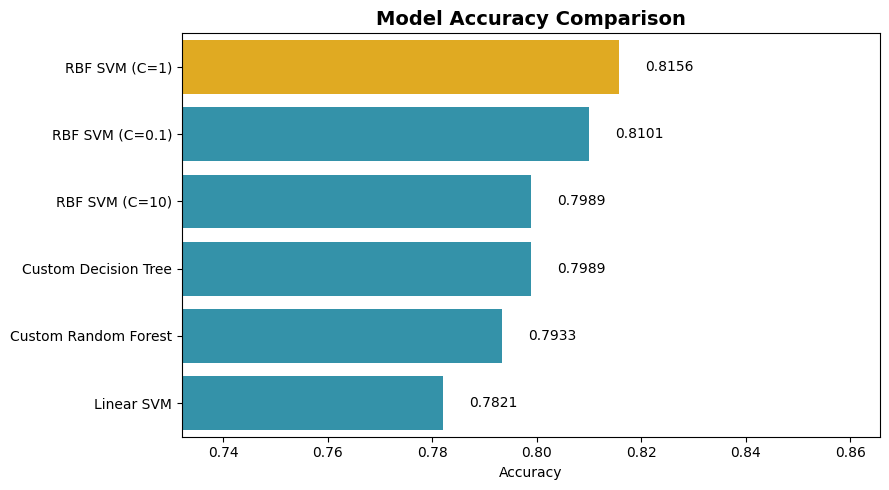

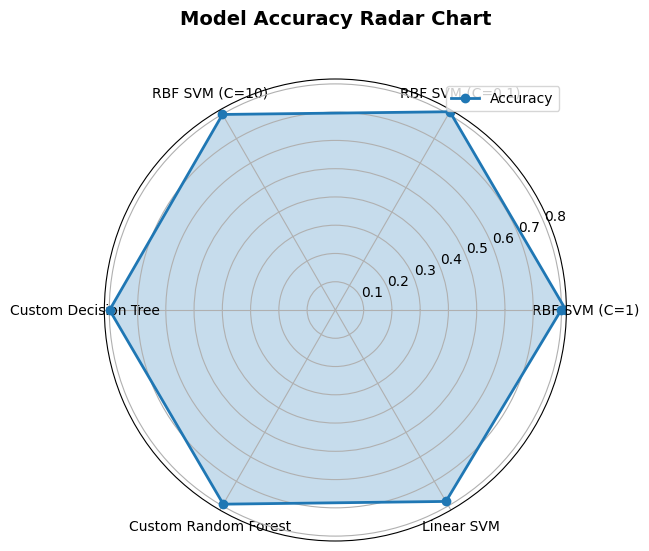

In [64]:
results = {
    "Custom Decision Tree": acc_tree,
    "Custom Random Forest": acc_forest,
    "Linear SVM": acc_linear
}
for c, acc in acc_rbf.items():
    results[f"RBF SVM (C={c})"] = acc

# Convert to DataFrame
df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
df_results = df_results.sort_values(by="Accuracy", ascending=False)


# --- Bar Plot ---
plt.figure(figsize=(9,5))
colors = ["#FFB703" if i == 0 else "#219EBC" for i in range(len(df_results))]

sns.barplot(
    x="Accuracy",
    y="Model",
    data=df_results,
    hue="Model",
    palette=colors,
    legend=False
)

# Add accuracy labels on bars
for i, v in enumerate(df_results["Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center')

plt.title("Model Accuracy Comparison", fontsize=14, weight='bold')
plt.xlabel("Accuracy")
plt.ylabel("")
plt.xlim(min(df_results["Accuracy"]) - 0.05, max(df_results["Accuracy"]) + 0.05)
plt.tight_layout()
plt.show()


# Radar chart
labels = df_results["Model"]
values = df_results["Accuracy"]
values = np.append(values, values[0])  # Close the loop
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.append(angles, angles[0])

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.plot(angles, values, 'o-', linewidth=2, label="Accuracy")
ax.fill(angles, values, alpha=0.25)
ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
plt.title("Model Accuracy Radar Chart", fontsize=14, weight='bold', y=1.1)
plt.legend(loc='upper right')
plt.show()

**Analytical Question:**
1.  Looking at the RBF SVM results, how did changing the `C` parameter affect the model's accuracy? Based on the explanation above, what does your result suggest about the trade-off between a wide margin and fitting the training data for this problem?
2.  Compared to your Random Forest, what is one advantage and one disadvantage of using an SVM? (Consider factors like interpretability, training time, and prediction performance).

**Answer:**
1. As the C value increased from 0.1 to 10, the accuracy got better. This means the model fit the training data more closely and learned more details. But when C is high, the model can also overfit, meaning it might not work as well on new data. This means there is a trade-off:
a wide margin gives better generalization but less accuracy, while a narrow margin gives higher accuracy but may overfit the data.


2. Advantage:
The SVM (especially the Linear SVM with 0.7821 accuracy) performs close to the Random Forest (0.7542), showing it can handle complex patterns well and give good prediction performance.

Disadvantage:
However, the SVM (especially the RBF ones with 0.6536 and 0.6592 accuracy) can be slower to train and harder to interpret than the Random Forest, which is faster and easier to understand